## 1. 데이터 살펴보기
- 문제 : 당뇨병 진행도 예측
- 모델 : 다층퍼셉트론
- 데이터셋 : Scikit-learn 당뇨병 데이터셋
- 문제 유형 : 회귀
- 평가 지표 : MSE, 평균 제곱근 오차


In [7]:
from sklearn.datasets import load_diabetes

dataset = load_diabetes()
print(dataset.keys()) # 데이터셋 딕셔너리의 정보를 살펴본다.

# data : 학습할 특징 데이터
# target :예측할 1년 후의 당뇨병 진행도
# feature_names : 특징 이름
# DESCR : 데이터셋 설명
# print(dataset.DESCR)

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [14]:
import pandas as pd

df= pd.DataFrame(dataset.data, columns =dataset.feature_names)
df['target']=dataset.target

print(df.head()) # 데이터 프레임의 맨위부터 데이터 샘플을 출력

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 27.2 MB/s  0:00:00 eta 0:00:0136m0:00:01


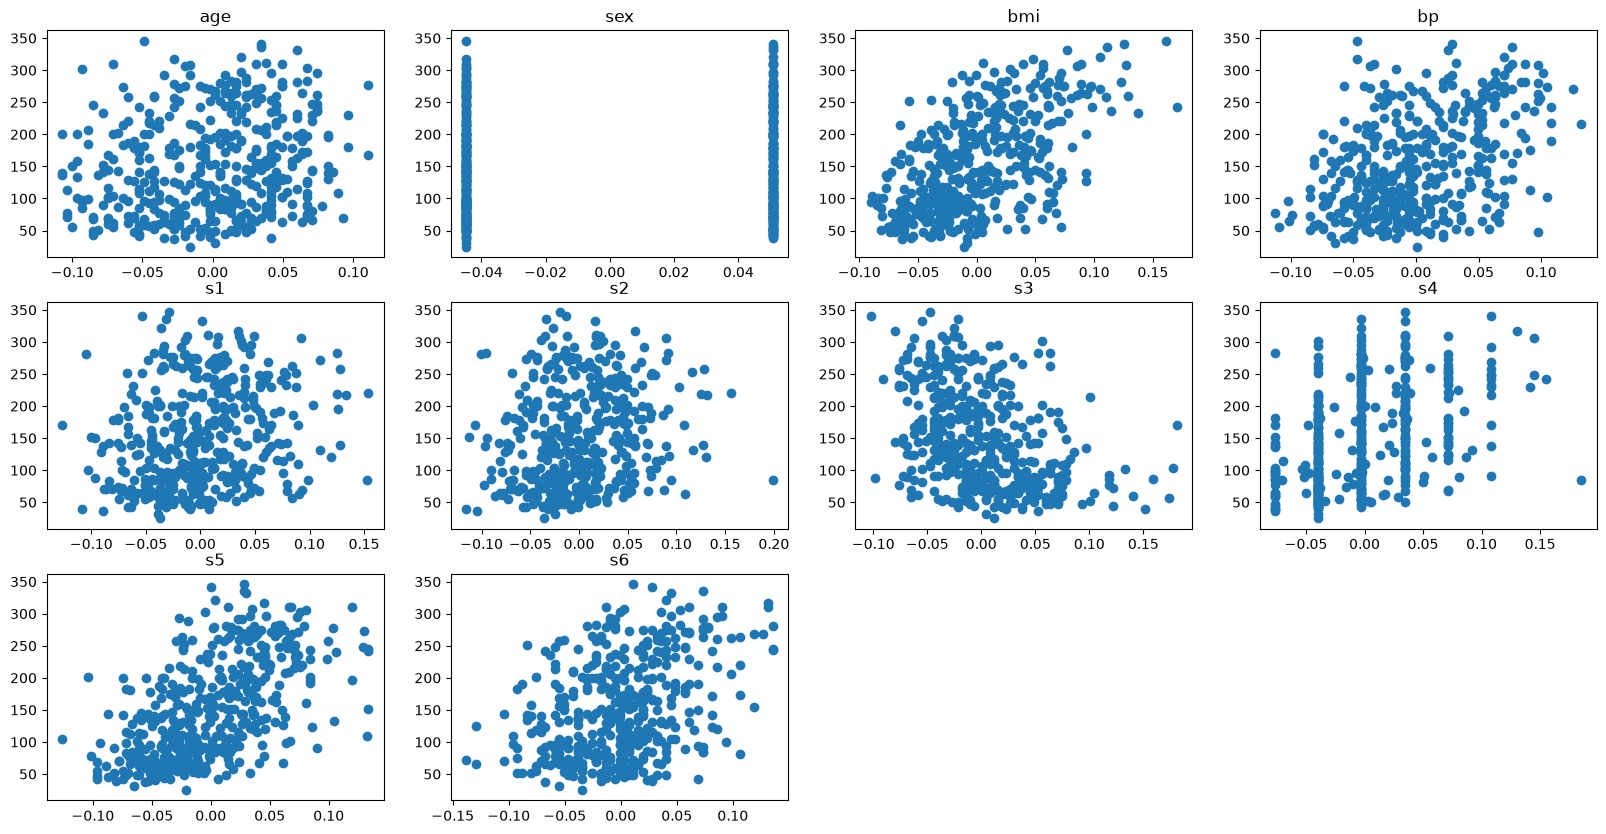

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
for i in range(10) :
    plt.subplot(3,4,i+1)
    plt.scatter(df.iloc[:,i],df['target']) #iloc 은 인덱스 제공
    plt.title(df.columns[i]) 
plt.show()

## 2. 모델 구현 및 학습

In [19]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(10,64),
    nn.ReLU(),
    nn.Linear(64,16),
    nn.ReLU(),
    nn.Linear(16,1)
    
)

X = torch.FloatTensor(df.iloc[:,:10].values)
Y = torch.FloatTensor(df['target'].values).reshape(-1,1)

batch_size = 64
learning_rate  = 1e-4
epochs = 30000

optimizer = torch.optim.SGD(params=model.parameters(), lr= learning_rate)

for epoch in range(epochs):
    
    #배치 설명
    for i in range(len(X) // batch_size):
        start = i * batch_size
        end = start + batch_size
        
        x= X[start:end]
        y= Y[start:end]
        optimizer.zero_grad()
        
        pred_y=model(x)

        loss = nn.MSELoss()(pred_y,y)
        loss.backward()
        optimizer.step()
        
        if epoch % 2000 == 0 :
            print("epoch:", epoch, "loss:", loss.item())
            
        
        
        
        
        
        
        
        
        

epoch: 0 loss: 23897.703125
epoch: 0 loss: 26260.748046875
epoch: 0 loss: 33214.72265625
epoch: 0 loss: 29800.7734375
epoch: 0 loss: 28299.765625
epoch: 0 loss: 33507.99609375
epoch: 2000 loss: 2630.4130859375
epoch: 2000 loss: 2596.911865234375
epoch: 2000 loss: 2387.984130859375
epoch: 2000 loss: 2966.19384765625
epoch: 2000 loss: 2758.91748046875
epoch: 2000 loss: 3174.12353515625
epoch: 4000 loss: 2755.97216796875
epoch: 4000 loss: 2510.5
epoch: 4000 loss: 2073.8369140625
epoch: 4000 loss: 2907.994384765625
epoch: 4000 loss: 2434.5595703125
epoch: 4000 loss: 2748.292724609375
epoch: 6000 loss: 2669.31689453125
epoch: 6000 loss: 2145.57861328125
epoch: 6000 loss: 1835.710693359375
epoch: 6000 loss: 2887.9091796875
epoch: 6000 loss: 2294.0517578125
epoch: 6000 loss: 2535.166015625
epoch: 8000 loss: 2734.76171875
epoch: 8000 loss: 1867.1297607421875
epoch: 8000 loss: 1292.652587890625
epoch: 8000 loss: 2467.67333984375
epoch: 8000 loss: 1832.876953125
epoch: 8000 loss: 2087.4904785156

## 3. 모델 성능 평가
- MAE, RMSE 값으로 성능을 측정해보겠다. 
- MAE :Mean Absolute Error
- MSE :Mean Square Error

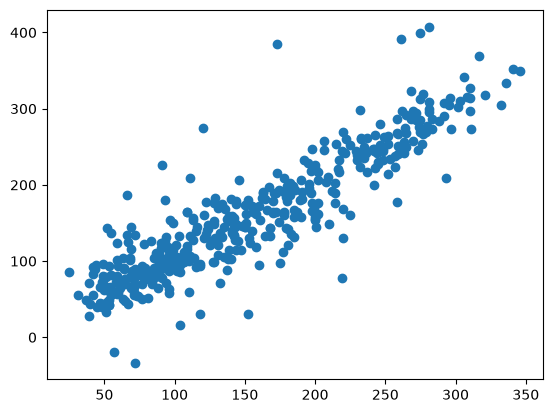

In [21]:
import matplotlib.pyplot as plt 

pred = model(torch.FloatTensor(X))
plt.scatter(Y.numpy(), pred.reshape(1,-1).clone().detach().numpy())

In [23]:
pred = model(torch.FloatTensor(X))
mae = (pred-Y).abs().mean()
rmse = ((pred-Y) **2).mean().sqrt()

print("MAE:", mae.item(), "RMSE:", rmse.item()) #item : 텐서에 저장된 데이터가 단일 값이면 반환

MAE: 24.144685745239258 RMSE: 35.33032989501953


- 위 성능 평가에서는 MAE 24 , RMSE 35가 나왔다. 
- 나아진 정도를 확인하기 위해 학습시키지 않은 모델의 예측값을 평가 지표로 구해보겠다.


MAE  152.20062255859375 RMSE 170.5718536376953


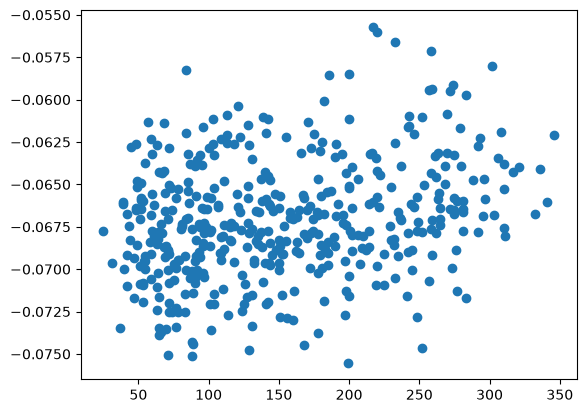

In [24]:
untrained_model = nn.Sequential(
    nn.Linear(10,64),
    nn.ReLU(),
    nn.Linear(64,16),
    nn.ReLU(),
    nn.Linear(16,1)
    )
pred = untrained_model(torch.FloatTensor(X))
plt.scatter(Y.numpy(),pred.reshape(1,-1).clone().detach().numpy())

pred = untrained_model(torch.FloatTensor(X))

mae = (pred-Y).abs().mean()
rmse = ((pred-Y)**2).mean().sqrt()

print("MAE ",mae.item(), "RMSE", rmse.item())

- 학습하지 않은 모델의 오차는 큰 것으로 판단된다. 산점도를 그려보았을 때도